# EDC Explorer

Pick one of the `.npz` files produced by `rir_hoa.py`, then compute and plot the
per-frequency-band Energy Decay Curve (EDC) for a chosen microphone / HOA channel,
using `analysis.compute_edc`.

**How to use:** run the cells top to bottom. Whenever you change a dropdown value,
re-run the cell(s) below it to refresh the results.

In [ ]:
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import pyfar as pf

import treble10_analyzer.analysis as analysis

## 1. Select an npz file

Update `DATA_ROOT` if your files live somewhere else (it should match the
`--output_dir` used with `rir_hoa.py`).

In [ ]:
DATA_ROOT = Path("/Users/dalsag1/Documents/datasets/treble10-npz")

npz_files = sorted(DATA_ROOT.rglob("*.npz"))
print(f"Found {len(npz_files)} npz files under {DATA_ROOT}")

# manual indexing of the file to analyze 
i_file = 0
# choose mic, HOA channel and octave-band resolution
i_mic, i_ch, fraction = 0, 0, 1

Found 3 npz files under /Users/dalsag1/Documents/datasets/treble10-npz


## 2. Load the selected file

`rir_hoa.py` saves one file per (room, source) with the RIRs of all mic positions
stacked along axis 0, so we reshape back to `(n_mics, n_samples, n_hoa_channels)`.

In [ ]:
def load_rir_file(path):
    data = np.load(path)
    fs = int(data["fs"])
    posMic = data["posMic"]  # (n_mics, 3)
    posSrc = data["posSrc"]  # (3,)
    n_mics = posMic.shape[0]
    rir = data["rir"].reshape(n_mics, -1, data["rir"].shape[-1])  # (n_mics, n_samples, n_hoa)
    return rir, fs, posMic, posSrc


rir, fs, posMic, posSrc = load_rir_file(npz_files[i_file])
n_mics, n_samples, n_hoa = rir.shape

print(f"Loaded: {str(npz_files[i_file])}")
print(f"  fs = {fs} Hz")
print(f"  {n_mics} mic positions, {n_samples} samples, {n_hoa} HOA channels (ACN order, channel 0 = W / omni)")
print(f"  source position = {posSrc}")

Loaded: /Users/dalsag1/Documents/datasets/treble10-npz/rir-hoa8/bathroom1/data_s0001.npz
  fs = 32000 Hz
  14 mic positions, 35201 samples, 81 HOA channels (ACN order, channel 0 = W / omni)
  source position = [-1.15 -4.98  1.15]


## 3. Compute and plot the EDC per frequency band

Uses `analysis.compute_edc(..., use_filterbank=True)`, which applies a fractional-octave
filterbank and Schroeder backward integration to each band.

/Users/dalsag1/Aalto Dropbox/Gloria Dal Santo/aalto/projects/treble10-analyzer/.venv/lib/python3.11/site-packages/pyfar/dsp/filter/fractional_octaves.py:292: UserWarning: The upper frequency limit 22387.2 Hz is above the Nyquist frequency. Using a highpass filter instead of a bandpass.
  sos = _coefficients_fractional_octave_bands(


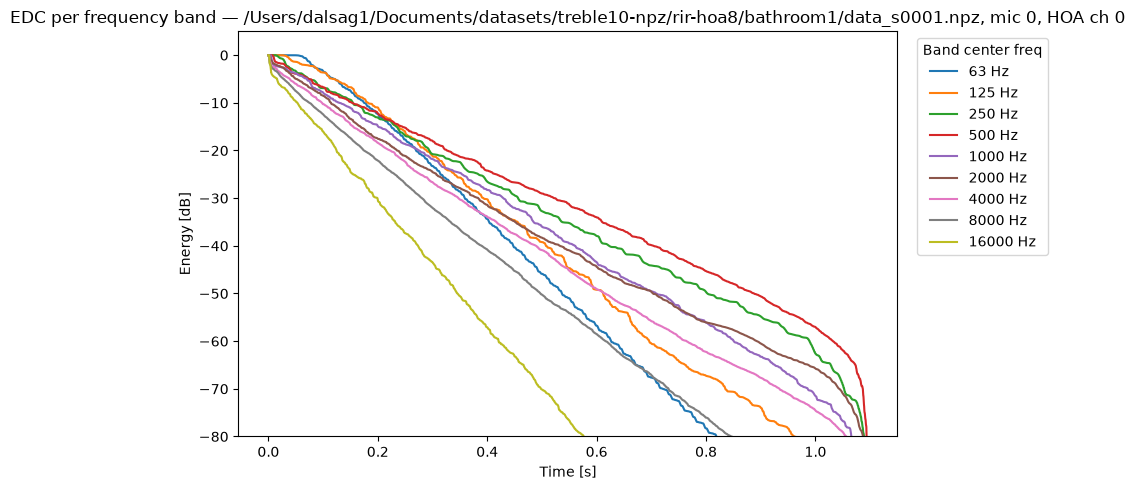

In [ ]:
F_MIN, F_MAX = 63, 16000


def get_center_frequencies(n_fractions, f_min=F_MIN, f_max=F_MAX):
    return pf.dsp.filter.fractional_octave_frequencies(
        num_fractions=n_fractions, frequency_range=(f_min, f_max), return_cutoff=False
    )[0]


def compute_band_edc(rir, mic_idx, hoa_channel, fs, n_fractions):
    x = rir[mic_idx, :, hoa_channel]
    x_t = torch.from_numpy(x).float().unsqueeze(0)  # (1, n_samples)
    edc_db = analysis.compute_edc(
        x_t, use_filterbank=True, n_fractions=n_fractions, f_min=F_MIN, f_max=F_MAX, fs=fs
    )  # (n_bands, n_samples)
    center_freqs = get_center_frequencies(n_fractions)
    return edc_db, center_freqs


edc_db, center_freqs = compute_band_edc(
    rir, i_mic, i_ch, fs, fraction
)
time = np.arange(edc_db.shape[-1]) / fs

fig, ax = plt.subplots(figsize=(9, 5))
for band_edc, f_c in zip(edc_db.numpy(), center_freqs):
    ax.plot(time, band_edc, label=f"{f_c:.0f} Hz")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Energy [dB]")
ax.set_ylim(-80, 5)
ax.set_title(f"EDC per frequency band \u2014 {str(npz_files[i_file])}, mic {i_mic}, HOA ch {i_ch}")
ax.legend(title="Band center freq", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

## 4. RT60 per band

Fits `analysis.estimate_rt60` to each band's EDC using the default -5 dB to -35 dB decay range.

In [ ]:
time_t = torch.arange(edc_db.shape[-1]) / fs

print(f"{'Freq [Hz]':>10}  {'RT60 [s]':>10}")
for band_edc, f_c in zip(edc_db, center_freqs):
    rt60, slope, intercept, valid_range = analysis.estimate_rt60(band_edc, time_t)
    print(f"{f_c:10.0f}  {rt60:10.3f}")

## 5. Multislope Analysis 


In [ ]:
import multislope

net = multislope.DecayFitNet(sample_rate=fs)
fit = net.estimate(rir[i_mic, :, i_ch])

print(fit)
# DecayFit(method='DecayFitNet', sample_rate=48000)
#      125 Hz  T = [0.690] s  A = [0.963]  N = 1.9e-08
#      250 Hz  T = [0.530, 2.303] s  A = [0.787, 0.0634]  N = 1.15e-09
#   ...

fit.t          # (n_bands, n_slopes) decay times in seconds; 0 marks an inactive slope
fit.a          # (n_bands, n_slopes) amplitudes, linear scale
fit.n          # (n_bands, 1) noise floor, linear scale
fit.n_slopes   # (n_bands,) number of active slopes per band